In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv('patient1.csv')
print(df.columns)

Index(['id', 'sex', 'birth_year', 'country', 'region', 'group',
       'infection_reason', 'infection_order', 'infected_by', 'contact_number',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')


In [4]:
df =pd.read_csv("patient1.csv")
print(df.head())
print(df.info())

   id     sex  birth_year country               region group infection_reason  \
0   1  female      1984.0   China  filtered at airport   NaN   visit to Wuhan   
1   2    male      1964.0   Korea  filtered at airport   NaN   visit to Wuhan   
2   3    male      1966.0   Korea         capital area   NaN   visit to Wuhan   
3   4    male      1964.0   Korea         capital area   NaN   visit to Wuhan   
4   5    male      1987.0   Korea         capital area   NaN   visit to Wuhan   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0              1.0          NaN            45.0     2020-01-20    2020-02-06   
1              1.0          NaN            75.0     2020-01-24    2020-02-05   
2              1.0          NaN            16.0     2020-01-26    2020-02-12   
3              1.0          NaN            95.0     2020-01-27    2020-02-09   
4              1.0          NaN            31.0     2020-01-30           NaN   

  deceased_date     state  
0   

In [9]:
date_cols = ['confirmed_date', 'released_date', 'deceased_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create age
df['age'] = 2020 - df['birth_year']

# Recovery time (in days)
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Clean unrealistic values
df = df[(df['age'] > 0) & (df['age'] < 110)]

In [6]:
df = df.dropna(subset=['birth_year'])   # important
df['age'] = 2020 - df['birth_year']

In [7]:
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

In [8]:
df = df.dropna(subset=['recovery_days'])

df = df[(df['age'] > 0) & (df['age'] < 110)]

print(df.shape)  

(28, 16)


In [9]:
X = df[["age"]]     # ✅ only age
y = df["recovery_days"]

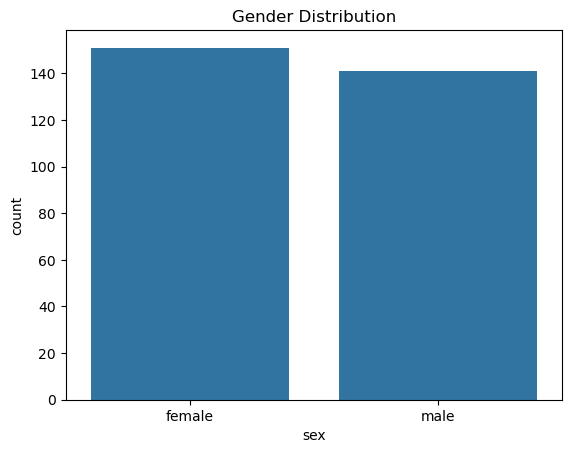

In [10]:
plt.figure()
sns.countplot(data=df, x='sex')
plt.title("Gender Distribution")
plt.show()

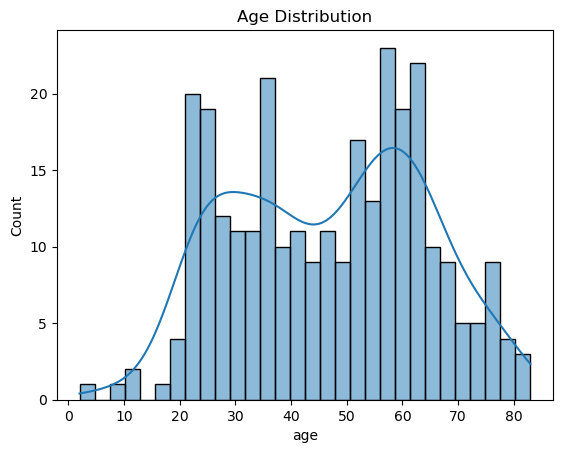

In [11]:
plt.figure()
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

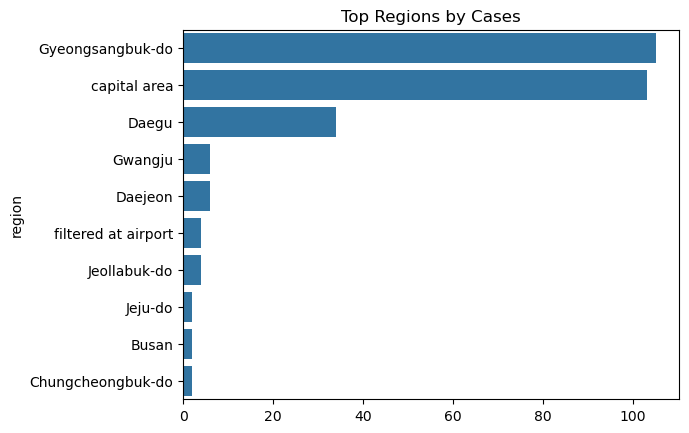

In [12]:
top_regions = df['region'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title("Top Regions by Cases")
plt.show()

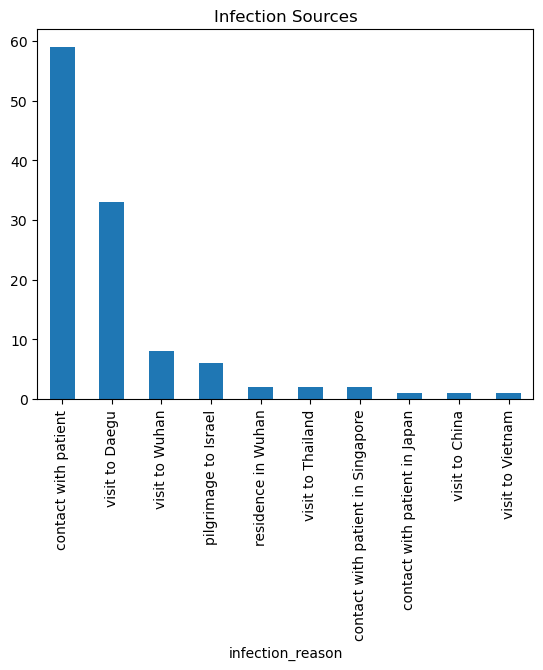

In [13]:
plt.figure()
df['infection_reason'].value_counts().head(10).plot(kind='bar')
plt.title("Infection Sources")
plt.show()

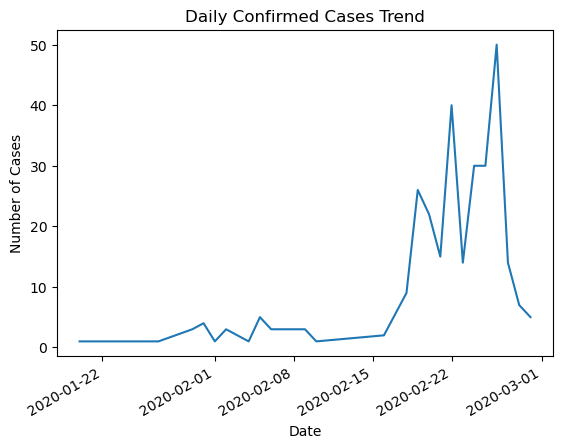

In [14]:
daily_cases = df.groupby('confirmed_date').size()

plt.figure()
daily_cases.plot()
plt.title("Daily Confirmed Cases Trend")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

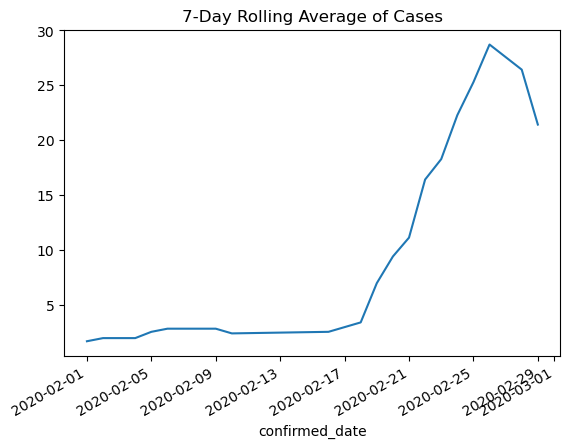

In [15]:
rolling_cases = daily_cases.rolling(window=7).mean()

plt.figure()
rolling_cases.plot()
plt.title("7-Day Rolling Average of Cases")
plt.show()

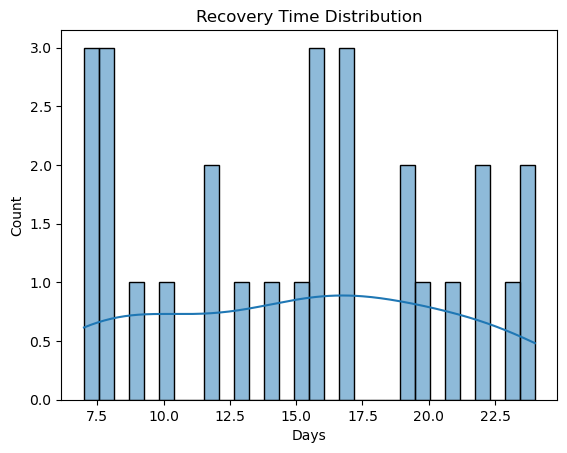

In [16]:
plt.figure()
sns.histplot(df['recovery_days'].dropna(), bins=30, kde=True)
plt.title("Recovery Time Distribution")
plt.xlabel("Days")
plt.show()

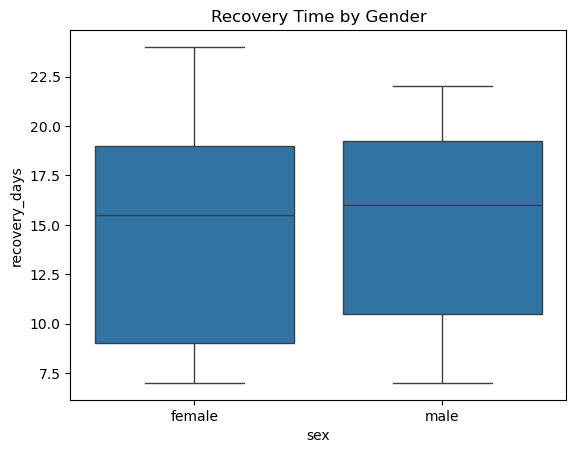

In [17]:
plt.figure()
sns.boxplot(data=df, x='sex', y='recovery_days')
plt.title("Recovery Time by Gender")
plt.show()

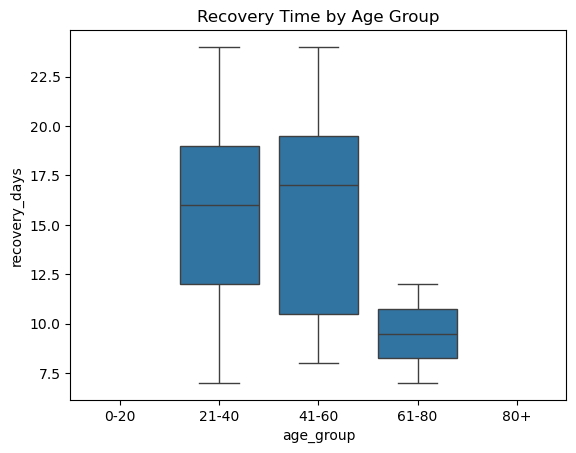

In [18]:
df['age_group'] = pd.cut(df['age'], bins=[0,20,40,60,80,100],
                         labels=['0-20','21-40','41-60','61-80','80+'])

plt.figure()
sns.boxplot(data=df, x='age_group', y='recovery_days')
plt.title("Recovery Time by Age Group")
plt.show()

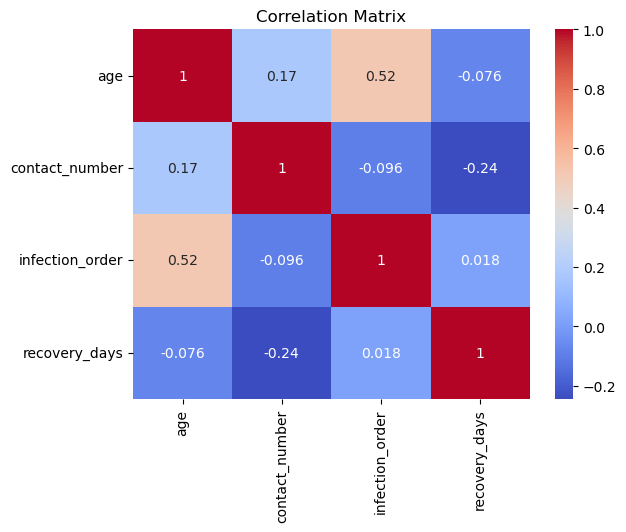

In [19]:
corr_df = df[['age', 'contact_number', 'infection_order', 'recovery_days']]

plt.figure()
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Prepare data
model_df = df[['age', 'contact_number', 'infection_order', 'recovery_days']].dropna()

X = model_df[['age', 'contact_number', 'infection_order']]
y = model_df['recovery_days']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
print("Model Score:", model.score(X_test, y_test))
print("Coefficients:", model.coef_)

Model Score: -7.7876771557266125
Coefficients: [ 0.15024098 -0.05828484 -0.44235362]


In [22]:
df.groupby('age')
['recovery_days']

['recovery_days']

In [23]:
df.groupby('age')['recovery_days'].mean()

age
2.0    NaN
9.0    NaN
11.0   NaN
16.0   NaN
19.0   NaN
        ..
77.0   NaN
78.0   NaN
79.0   NaN
82.0   NaN
83.0   NaN
Name: recovery_days, Length: 67, dtype: float64

In [24]:
df[['contact_number', 'recovery_days']].corr()

,contact_number,recovery_days
contact_number,1.000000,-0.244144
recovery_days,-0.244144,1.000000


In [25]:
df.groupby('confirmed_date').size()

confirmed_date
2020-01-20     1
2020-01-24     1
2020-01-26     1
2020-01-27     1
2020-01-30     3
2020-01-31     4
2020-02-01     1
2020-02-02     3
2020-02-04     1
2020-02-05     5
2020-02-06     3
2020-02-09     3
2020-02-10     1
2020-02-16     2
2020-02-18     9
2020-02-19    26
2020-02-20    22
2020-02-21    15
2020-02-22    40
2020-02-23    14
2020-02-24    30
2020-02-25    30
2020-02-26    50
2020-02-27    14
2020-02-28     7
2020-02-29     5
dtype: int64

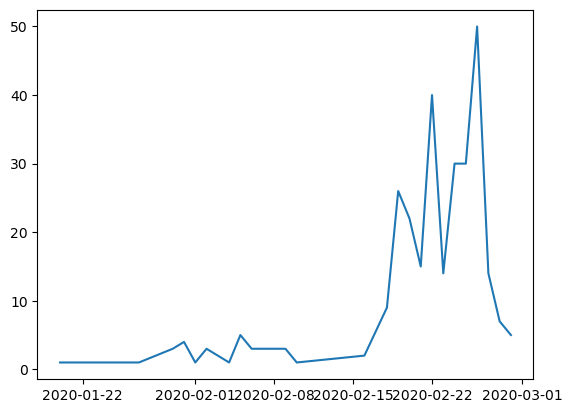

In [26]:
plt.plot(df.groupby('confirmed_date').size())

In [27]:
df['region'].value_counts()

region
Gyeongsangbuk-do       105
capital area           103
Daegu                   34
Gwangju                  6
Daejeon                  6
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Ulsan                    2
Gangwon-do               1
Chungcheongnam-do        1
Name: count, dtype: int64

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


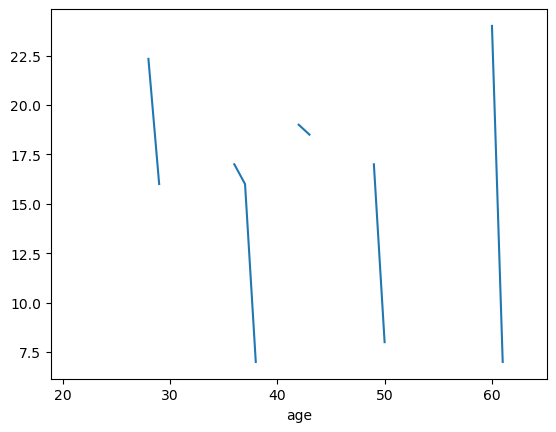

In [32]:
df.groupby('age')['recovery_days'].mean().plot()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.0050868901027785185


In [12]:
import pandas as pd

# Load your file
df = pd.read_csv("patient1.csv")

# Check first few rows
print(df.head())

# Check columns
print(df.columns)

# Check shape (rows, columns)
print(df.shape)

   id     sex  birth_year country               region group infection_reason  \
0   1  female      1984.0   China  filtered at airport   NaN   visit to Wuhan   
1   2    male      1964.0   Korea  filtered at airport   NaN   visit to Wuhan   
2   3    male      1966.0   Korea         capital area   NaN   visit to Wuhan   
3   4    male      1964.0   Korea         capital area   NaN   visit to Wuhan   
4   5    male      1987.0   Korea         capital area   NaN   visit to Wuhan   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0              1.0          NaN            45.0     2020-01-20    2020-02-06   
1              1.0          NaN            75.0     2020-01-24    2020-02-05   
2              1.0          NaN            16.0     2020-01-26    2020-02-12   
3              1.0          NaN            95.0     2020-01-27    2020-02-09   
4              1.0          NaN            31.0     2020-01-30           NaN   

  deceased_date     state  
0   

In [15]:
print(df.shape)

(4212, 14)


In [16]:
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'])
df['released_date'] = pd.to_datetime(df['released_date'])

# Create age (from birth_year)
df['age'] = 2020 - df['birth_year']

# Create recovery days
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Remove missing values
df = df.dropna(subset=['age', 'recovery_days'])

# Check
print(df[['age', 'recovery_days']].head())
print(df.shape)

    age  recovery_days
0  36.0           17.0
1  56.0           12.0
2  54.0           17.0
3  56.0           13.0
5  56.0           20.0
(28, 16)


In [17]:
X = df[["age"]]
y = df["recovery_days"]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.0050868901027785185


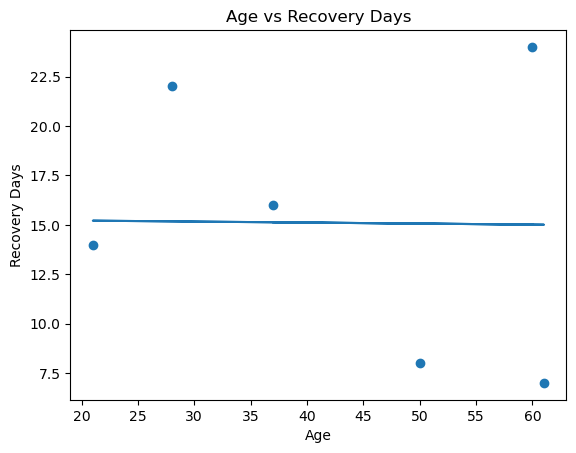

In [20]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Age")
plt.ylabel("Recovery Days")
plt.title("Age vs Recovery Days")
plt.show()